# 신고자 vs 구급대원 음성 분류 (Wav2Vec2)

## 목적
성별 분류 전에 **신고자 발화만 필터링**하기 위해,  
음성만 보고 신고자 / 구급대원을 구별하는 2-class 분류 모델을 만든다.

## 레이블 생성 전략 (정답지가 없어도 되는 이유)
119 신고 통화에서 구급대원은 반드시 첫 마디에 **"119입니다" / "상황실입니다"** 를 말한다.
→ 파일마다 이 키워드가 있는 발화의 speaker 번호를 구급대원으로 확정하고,
  그 speaker의 **모든** 발화를 구급대원(1), 나머지를 신고자(0)로 레이블.

```
음성 파일 → 파일별 speaker 식별 → CSV 저장 (런타임 복구용)
          → Wav2Vec2 fine-tuning
          → mission1_gender_cnn.ipynb에서 신고자 필터로 사용
```

In [3]:
import sys, subprocess
for pkg in ['transformers', 'librosa', 'soundfile', 'accelerate']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
    print(f'{pkg} 완료')
print('\n설치 완료!')

transformers 완료
librosa 완료
soundfile 완료
accelerate 완료

설치 완료!


In [4]:
import os, json, glob
import numpy as np
import librosa
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {device}')

디바이스: cpu


## 1. Drive 마운트 & 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE     = '/content/drive/MyDrive/Colab Notebooks/2.신주아/대학부 데이터'
WORK_DIR = '/content/drive/MyDrive/Colab Notebooks/2.신주아'

PATHS = {
    'train_wav' : f'{BASE}/Training/1.원천데이터/TS_서울_구급',
    'train_json': f'{BASE}/Training/2.라벨링데이터/TL_서울_구급',
    'val_wav'   : f'{BASE}/Validation/1.원천데이터/VS_서울_구급',
    'val_json'  : f'{BASE}/Validation/2.라벨링데이터/VL_서울_구급',
}

TRAIN_CSV       = f'{WORK_DIR}/spk_train.csv'
VAL_CSV         = f'{WORK_DIR}/spk_val.csv'
MODEL_PATH      = f'{WORK_DIR}/wav2vec2_speaker_type.pth'
CHECKPOINT_PATH = f'{WORK_DIR}/wav2vec2_checkpoint.pth'

SR = 16000

print('경로 설정 완료')
for k, v in PATHS.items():
    print(f'  {k}: {v}')

## 2. 파일별 speaker 레이블 파싱 & CSV 저장

파일마다 "119" / "상황실" 키워드가 있는 발화의 speaker 번호를 구급대원으로 확정한다.
키워드를 찾지 못한 파일은 레이블 불확실하므로 제외.

In [ ]:
# 구급대원이 통화 초반에 반드시 쓰는 강한 식별 키워드
DISPATCHER_KEYWORDS = ['119', '상황실']


def find_dispatcher_speaker(utterances):
    """파일 내에서 구급대원 speaker_id를 반환. 못 찾으면 None."""
    for utt in utterances:
        text = utt.get('text', '')
        if any(kw in text for kw in DISPATCHER_KEYWORDS):
            return utt['speaker']
    return None


def parse_labels(json_dir, wav_dir, min_dur=0.3):
    """모든 JSON/WAV 쌍을 파싱해 레이블 DataFrame 반환."""
    records  = []
    skipped  = 0
    json_files = (
        glob.glob(os.path.join(json_dir, '*.json')) +
        glob.glob(os.path.join(json_dir, '**/*.json'), recursive=True)
    )

    for jpath in json_files:
        stem     = os.path.splitext(os.path.basename(jpath))[0]
        wav_path = os.path.join(wav_dir, stem + '.wav')
        if not os.path.exists(wav_path):
            found = glob.glob(os.path.join(wav_dir, '**', stem + '.wav'), recursive=True)
            if not found:
                continue
            wav_path = found[0]

        with open(jpath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        utterances = data.get('utterances', [])
        if not utterances:
            continue

        # 파일별로 구급대원 speaker 번호 식별
        disp_spk = find_dispatcher_speaker(utterances)
        if disp_spk is None:
            skipped += 1
            continue  # 키워드 없는 파일은 제외

        for utt in utterances:
            start_s = utt['startAt'] / 1000.0
            end_s   = utt['endAt']   / 1000.0
            dur     = end_s - start_s
            if dur < min_dur:
                continue
            records.append({
                'wav_path': wav_path,
                'start_ms': utt['startAt'],
                'end_ms'  : utt['endAt'],
                'duration': round(dur, 3),
                'speaker' : utt['speaker'],
                'label'   : 1 if utt['speaker'] == disp_spk else 0,
            })

    df = pd.DataFrame(records)
    print(f'발화: {len(df)}개  |  키워드 없어 제외된 파일: {skipped}개')
    print(df['label'].value_counts().rename({0: '신고자(0)', 1: '구급대원(1)'}))
    return df


print('파싱 함수 정의 완료')

In [ ]:
# CSV가 있으면 로드, 없으면 파싱 후 저장 (런타임 끊겨도 재실행 가능)
if os.path.exists(TRAIN_CSV) and os.path.exists(VAL_CSV):
    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)
    print(f'CSV 로드 완료  →  Train: {len(train_df)}  Val: {len(val_df)}')
else:
    print('── Train 파싱 중 ──')
    train_df = parse_labels(PATHS['train_json'], PATHS['train_wav'])
    print('\n── Val 파싱 중 ──')
    val_df   = parse_labels(PATHS['val_json'],   PATHS['val_wav'])
    train_df.to_csv(TRAIN_CSV, index=False)
    val_df.to_csv(VAL_CSV,   index=False)
    print(f'\nCSV 저장 완료 → {TRAIN_CSV}')

## 3. PyTorch Dataset 구성

Wav2Vec2FeatureExtractor로 raw waveform → 모델 입력 변환

In [ ]:
MODEL_NAME = 'facebook/wav2vec2-base'

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
print(f'Feature Extractor 로드: {MODEL_NAME}')

MAX_LEN = int(5.0 * SR)  # 최대 5초


class SpeakerDataset(Dataset):
    """CSV 경로 기반 Dataset — 오디오를 __getitem__에서 직접 로드"""
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # WAV에서 해당 구간만 로드 (offset + duration으로 효율적으로 읽기)
        audio, _ = librosa.load(
            row['wav_path'], sr=SR,
            offset=row['start_ms'] / 1000.0,
            duration=row['duration'],
        )
        audio = audio.astype(np.float32)
        # 패딩 / 자름
        if len(audio) < MAX_LEN:
            audio = np.pad(audio, (0, MAX_LEN - len(audio)))
        else:
            audio = audio[:MAX_LEN]

        inputs = feature_extractor(audio, sampling_rate=SR,
                                   return_tensors='pt', padding=False)
        return {
            'input_values': inputs['input_values'].squeeze(0),
            'label'       : torch.tensor(int(row['label']), dtype=torch.long),
        }


train_ds = SpeakerDataset(train_df)
val_ds   = SpeakerDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=8,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)}  |  Val: {len(val_ds)}')
batch = next(iter(train_loader))
print(f'input shape: {batch["input_values"].shape}')

## 4. Wav2Vec2 Fine-tuning

- Feature extractor (CNN layers) 는 freeze
- Transformer + classifier 만 학습 (메모리/시간 절약)

In [9]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
)

# Feature extractor(CNN) freeze → Transformer만 학습
model.freeze_feature_encoder()
model = model.to(device)

train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'학습 파라미터: {train_params:,}')

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 14674.15it/s]
[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


학습 파라미터: 90,368,642


In [ ]:
import torch.optim as optim

EPOCHS = 10
LR     = 1e-4

# 클래스 불균형 처리 (신고자 발화 >> 구급대원 발화)
counts  = train_df['label'].value_counts().sort_index().values
weights = torch.tensor(1.0 / counts, dtype=torch.float).to(device)
weights = weights / weights.sum()
criterion = torch.nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── 체크포인트에서 재개 ────────────────────────────────────────────────────────
start_epoch = 1
best_acc    = 0.0
history     = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt['epoch'] + 1
    best_acc    = ckpt['best_val_acc']
    history     = ckpt['history']
    print(f'체크포인트 재개: {start_epoch}epoch부터  |  최고 Val Acc: {best_acc:.4f}')
else:
    print('처음부터 학습 시작')

# ── 학습 루프 ─────────────────────────────────────────────────────────────────
print(f'\n{"Epoch":>6} {"TrLoss":>8} {"TrAcc":>7} {"ValLoss":>8} {"ValAcc":>7}')
print('─' * 45)

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    tr_loss, tr_correct, tr_n = 0, 0, 0
    for batch in train_loader:
        iv     = batch['input_values'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(iv).logits
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * labels.size(0)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_n       += labels.size(0)

    model.eval()
    val_loss, val_correct, val_n = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            iv     = batch['input_values'].to(device)
            labels = batch['label'].to(device)
            out  = model(iv).logits
            loss = criterion(out, labels)
            val_loss    += loss.item() * labels.size(0)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_n       += labels.size(0)

    scheduler.step()

    tr_l, tr_a   = tr_loss/tr_n,   tr_correct/tr_n
    val_l, val_a = val_loss/val_n, val_correct/val_n
    history['train_loss'].append(tr_l)
    history['train_acc'].append(tr_a)
    history['val_loss'].append(val_l)
    history['val_acc'].append(val_a)

    tag = ''
    if val_a > best_acc:
        best_acc = val_a
        torch.save(model.state_dict(), MODEL_PATH)
        tag = ' ★'

    # 에폭마다 체크포인트 저장 (런타임 끊겨도 이어서 학습 가능)
    torch.save({
        'epoch'       : epoch,
        'model'       : model.state_dict(),
        'optimizer'   : optimizer.state_dict(),
        'scheduler'   : scheduler.state_dict(),
        'best_val_acc': best_acc,
        'history'     : history,
    }, CHECKPOINT_PATH)

    print(f'{epoch:>6} {tr_l:>8.4f} {tr_a:>7.4f} {val_l:>8.4f} {val_a:>7.4f}{tag}')

print(f'\n최고 Val Accuracy: {best_acc:.4f}')

## 5. 평가

              precision    recall  f1-score   support

      신고자(0)       0.80      1.00      0.89         4
     구급대원(1)       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



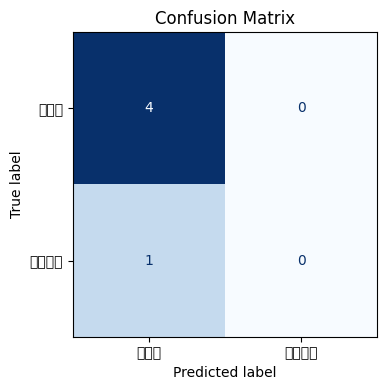

In [11]:
# 최고 모델 로드 후 평가
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        out = model(batch['input_values'].to(device)).logits
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())

print(classification_report(all_labels, all_preds,
                             target_names=['신고자(0)', '구급대원(1)']))

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['신고자', '구급대원'])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

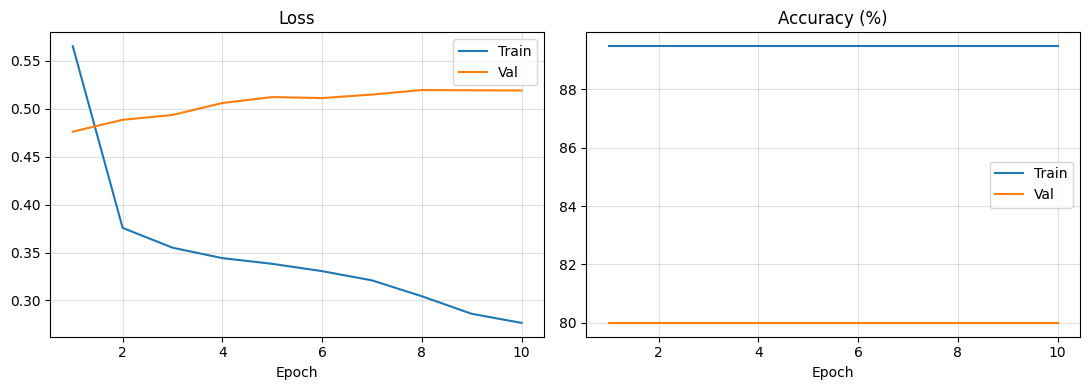

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
eps = range(1, EPOCHS + 1)
ax1.plot(eps, history['train_loss'], label='Train')
ax1.plot(eps, history['val_loss'],   label='Val')
ax1.set(title='Loss', xlabel='Epoch'); ax1.legend(); ax1.grid(alpha=0.4)
ax2.plot(eps, [a*100 for a in history['train_acc']], label='Train')
ax2.plot(eps, [a*100 for a in history['val_acc']],   label='Val')
ax2.set(title='Accuracy (%)', xlabel='Epoch'); ax2.legend(); ax2.grid(alpha=0.4)
plt.tight_layout(); plt.show()

## 6. 추론 — 음성 세그먼트가 신고자인지 구급대원인지 판별

In [13]:
def predict_speaker_type(audio_np, model, feature_extractor, device, sr=SR, max_len=MAX_LEN):
    """
    audio_np: float32 numpy array (raw waveform)
    return  : 0=신고자, 1=구급대원, confidence
    """
    model.eval()
    audio = audio_np.astype(np.float32)
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    inputs = feature_extractor(audio, sampling_rate=sr, return_tensors='pt', padding=False)
    with torch.no_grad():
        logits = model(inputs['input_values'].to(device)).logits
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    pred = int(probs.argmax())
    return pred, probs


# 샘플 파일 전체 발화에 적용해 결과 확인
JSON_PATH = '651e4a1fb7503416e5f162a0_20220302.json'
WAV_PATH  = '651e4a1fb7503416e5f162a0_20220302.wav'

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

y_full, _ = librosa.load(WAV_PATH, sr=SR)

print(f'신고자 성별(정답): {data["gender"]}')
print(f'{"#":>3}  {"speaker":>7}  {"예측":>6}  {"신고자확률":>9}  {"구급대원확률":>11}  text')
print('─' * 70)

for i, utt in enumerate(data['utterances']):
    seg   = y_full[int(utt['startAt']/1000*SR): int(utt['endAt']/1000*SR)]
    pred, probs = predict_speaker_type(seg, model, feature_extractor, device)
    label_str = '신고자' if pred == 0 else '구급대원'
    text  = utt.get('text', '')[:20]
    print(f'{i:>3}  {utt["speaker"]:>7}  {label_str:>6}  {probs[0]:>9.3f}  {probs[1]:>11.3f}  {text}')

신고자 성별(정답): M
  #  speaker      예측      신고자확률       구급대원확률  text
──────────────────────────────────────────────────────────────────────
  0        0     신고자      0.773        0.227  119입니다.
  1        1     신고자      0.735        0.265  예, 그 구급차가 지금 보내주셔야 할
  2        0     신고자      0.774        0.226  예, 누가 어디 아파요?
  3        1     신고자      0.774        0.226  엄마가 지금 가슴 쪽이 아프
  4        0     신고자      0.776        0.224  주소 불러주세요.
  5        1     신고자      0.774        0.226  서울특별시
  6        0     신고자      0.787        0.213  예.
  7        1     신고자      0.774        0.226  은평구 응암동
  8        0     신고자      0.779        0.221  예.
  9        1     신고자      0.775        0.225  응암 푸르지오 아파트
 10        0     신고자      0.786        0.214  응암 푸르지오?
 11        1     신고자      0.793        0.207  네.
 12        1     신고자      0.771        0.229  [개인정보]
 13        1     신고자      0.741        0.259  예, 올 때 그 좀 그 저 그 소리 
 14        0     신고자      0.799        0.201  네
 15        0     신고자      0.779

## 참고 — 다음 단계

학습 완료 후 `wav2vec2_speaker_type.pth` 를  
`mission1_gender_cnn.ipynb` 에서 불러와 신고자 필터로 사용.

```python
# mission1에서 사용 예시
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2ForSequenceClassification

spk_model = Wav2Vec2ForSequenceClassification.from_pretrained('facebook/wav2vec2-base', num_labels=2)
spk_model.load_state_dict(torch.load('wav2vec2_speaker_type.pth'))
spk_model.eval()

# 예측값 0 = 신고자 → 성별 분류에 사용
# 예측값 1 = 구급대원 → 제외
```